<span style="font-family: 'Times New Roman'; font-size: 12pt;">

# **A/B Testing Marketing**

<b>📌 Initial Analysis Description</b>

A marketing company is conducting an A/B testing experiment to evaluate the effectiveness of a digital advertising campaign.  
For this purpose, users are divided into two groups:

- **Treatment Group (ad)** → users who were exposed to the advertisement.  
- **Control Group (psa)** → users who only saw a public service announcement (PSA).  

The goal of this A/B test is to compare user behavior between the two groups in order to answer two key business questions:

1. **Did the advertising campaign lead to an increase in purchases?**  
2. **If so, how much of that increase can be directly attributed to the advertisement?**  

In other words, the main objective of this analysis is to evaluate the **impact of the ad campaign on user conversion**, compared to the control group.

---

<b>Data Dictionary</b>

| Column          | Description                                                                 |
|-----------------|------------------------------------------------------------------------------|
| `Index`         | Row index of the dataset                                                    |
| `user_id`       | Unique identifier for each user                                             |
| `test_group`    | User group: `"ad"` (exposed to advertisement) or `"psa"` (control group)     |
| `converted`     | Conversion status: `True` if the user made a purchase, `False` otherwise     |
| `total_ads`     | Total number of ads viewed by the user                                      |
| `most_ads_day`  | The day when the user viewed the most ads                                   |
| `most_ads_hour` | The hour of the day when the user saw the highest number of ads             |

---

</span>

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

<b>Objective of Descriptive Analysis</b>

Before conducting the A/B testing, the first step is to perform a **descriptive analysis** of the dataset. This analysis aims to:

1. Understand the data distribution for each group (treatment vs. control).  
2. Assess data quality by checking for duplicates, overlapping users between groups, and sample size balance.  
3. Describe user behavior patterns, such as the number of ads viewed, the day or hour with the highest ad exposure, and the baseline conversion rate.  
4. Provide initial context for the A/B test, so that inferential results can be interpreted more effectively.  

Through descriptive analysis, the company can obtain an early understanding of how the campaign is being run and whether there are initial indications of behavioral differences between the ad group and the control group.

---

<b>Analysis Process:</b>

1. Data Cleaning  
2. Data Validation  
3. Exploratory Data Analysis (EDA)  
4. Assumption Testing for Z-Test  
5. A/B Testing using Z-Test  
6. Conversion Rate Analysis by <br> 
   - Most Ads Day  
   - Most Ads Hour  
   - Is Weekend  
   - Time of Day  
7. Conclusion  

</span>

In [52]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import statsmodels.api as sm
import statsmodels.stats.power as smp

# Load The Dataset
df_marketing = pd.read_csv(r'C:\Users\Asus\Downloads\marketing_AB.csv', index_col=0)
df_marketing.head(5)

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [53]:
# Cheking Count of Columns and Rows
df_marketing.shape

(588101, 6)

In [54]:
# Information About The Dataset
df_marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


In [55]:
# Rename Columns 
df_marketing.rename(columns=
                    {'user id':'user_id',
                     'test group':'test_group',
                     'total ads':'total_ads',
                     'most ads day':'most_ads_day',
                     'most ads hour':'most_ads_hour'},
                     inplace=True)

In [56]:
# Backup Dataset Before Data Cleaning
df_marketing_back_up = df_marketing.copy(deep=True)

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

## 🔧 Initial Data Preparation

Before performing *data cleaning*, the initial steps include:

1. **Importing Libraries** → Load the required Python libraries and modules.  
2. **Loading Dataset** → Read the dataset into the working environment.  
3. **Checking Dataset Dimensions** → Confirm the shape of the dataset (588,101 rows and 6 columns).  
4. **Reviewing Dataset Information** → Inspect data types and non-null counts for each column.  
5. **Standardizing Column Names** → Ensure column names are consistent and easy to work with.  
6. **Creating Backup Copy** → Preserve a backup of the original dataset before starting the cleaning process.  

</span>

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

## Data Cleaning

### 🔎 Process
1. **Check Data Types** → Verify the data type of each column.  
2. **Check Missing Values** → Ensure no null values are present.  
3. **Check Duplicates** → Detect duplicate rows.  
4. **Check Unique Values** → Explore unique values for categorical columns.  
5. **Check for Anomalies**:  
   - `total_ads` must not contain negative values.  
   - `most_ads_hour` must be within the range 0–23.  
6. **Feature Engineering**: Create new variables `is_weekend` and `time_of_day`.  
7. **Descriptive Analysis**: Analyze `total_ads` and `most_ads_hour` distributions to detect potential anomalies.  
8. **Outlier Detection**: Calculate Z-scores for `total_ads`.  
9. **Outlier Removal**: Remove rows flagged as outliers based on Z-scores.   
</span>

In [57]:
# Cheking Type Dataset
df_marketing.dtypes

user_id          int64
test_group         str
converted         bool
total_ads        int64
most_ads_day       str
most_ads_hour    int64
dtype: object

In [58]:
# Cheking Missing Values
df_marketing.isnull().sum()

user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [59]:
# Cheking Data Duplicate
df_marketing.duplicated().sum()

np.int64(0)

In [60]:
# Cheking Unique Values To Data Categorical
cat_cols = ['user_id', 'test_group', 'converted', 'most_ads_day']

for col in cat_cols:
    unique_values = df_marketing[col].unique()
    print(f'{col}: {len(unique_values)} unique values')
    print(f'Unique Values:{col}: {unique_values}\n')

user_id: 588101 unique values
Unique Values:user_id: [1069124 1119715 1144181 ... 1038442 1496395 1237779]

test_group: 2 unique values
Unique Values:test_group: <StringArray>
['ad', 'psa']
Length: 2, dtype: str

converted: 2 unique values
Unique Values:converted: [False  True]

most_ads_day: 7 unique values
Unique Values:most_ads_day: <StringArray>
['Monday', 'Tuesday', 'Friday', 'Saturday', 'Wednesday', 'Sunday', 'Thursday']
Length: 7, dtype: str



In [61]:
# Checking for Data Anomalies in The 'total_ads' Column
anomaly_total_ads = df_marketing[df_marketing['total_ads'] < 0]
print(f'Count of anomaly total_ads (negative values): {len(anomaly_total_ads)}')

Count of anomaly total_ads (negative values): 0


In [62]:
# Cheking for Data Anomalies in 'most_ads_hour' Column
anomaly_most_ads_hour = df_marketing[(df_marketing
['most_ads_hour'] < 0) | (df_marketing['most_ads_hour'] > 23)]
print(f'Count of anomaly most_ads_hour: {len(anomaly_most_ads_hour)}')

Count of anomaly most_ads_hour: 0


In [63]:
# Feature Enginering 'is_weekend'
df_marketing['is_weekend'] = df_marketing['most_ads_day'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

In [64]:
# Feature Enginering time_of day
def time_of_day(hour):
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 22:
        return 'Evening'
    else:
        return 'Night'

df_marketing['time_of_day'] = df_marketing['most_ads_hour'].apply(time_of_day)

In [65]:
# Summary Statistics to Identify Outliers or Unusual Values
df_marketing[['total_ads', 'most_ads_hour']].describe().round().astype(int)

,total_ads,most_ads_hour
count,588101,588101
mean,25,14
std,44,5
min,1,0
25%,4,11
50%,13,14
75%,27,18
max,2065,23


In [66]:
# Identifying Outliers Using Z-Score Method
df_marketing['zscore_total_ads'] = zscore(df_marketing['total_ads'])

outliers = df_marketing[abs(df_marketing['zscore_total_ads']) > 3]
print(f"Count Of Outlier: {len(outliers)}")

Count Of Outlier: 10031


In [67]:
# Outlier Ratio per Test Group (%)
outlier_ratio = (
    outliers['test_group'].value_counts() / df_marketing['test_group'].value_counts() * 100
).round(2)
outlier_ratio

test_group
ad     1.70
psa    1.92
Name: count, dtype: float64

In [68]:
# Filtering Outliers
df_marketing = df_marketing[df_marketing['zscore_total_ads'] < 3] 

In [69]:
# Cheking Outliers
outliers = df_marketing[abs(df_marketing['zscore_total_ads']) > 3]
print(f"Count Of Outlier: {len(outliers)}")

Count Of Outlier: 0


In [70]:
# Final Dataset
df_marketing.head(5)

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,is_weekend,time_of_day,zscore_total_ads
0,1069124,ad,False,130,Monday,20,Weekday,Evening,2.406011
1,1119715,ad,False,93,Tuesday,22,Weekday,Evening,1.559623
2,1144181,ad,False,21,Tuesday,18,Weekday,Evening,-0.087404
7,1496843,ad,False,17,Sunday,18,Weekend,Evening,-0.178905
8,1448851,ad,False,21,Tuesday,19,Weekday,Evening,-0.087404


<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### ✅ Data Cleaning Results
- **Data Types**: Already standardized, no changes required.  
- **Missing Values**: None found.  
- **Duplicates**: None found.  

**Unique Values**:  
- `user_id`: 588,101 unique values  
  Example: [1069124, 1119715, 1144181, …, 1038442, 1496395, 1237779]  
- `test_group`: 2 unique values → ['ad', 'psa']  
- `converted`: 2 unique values → [False, True]  
- `most_ads_day`: 7 unique values → ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']  

**Anomaly Checks**:  
- No negative values in `total_ads`.  
- All `most_ads_hour` values fall within 0–23.  

**Outlier Analysis**:  
- Maximum `total_ads` = 2065 (identified as outlier).  
- Z-score confirms **10,031 outliers** in `total_ads`.  

**Outlier Distribution by Group**:  
- `ad`: 1.70%  
- `psa`: 1.92%  

➡️ **Decision**: Outliers were removed, as the dataset is very large (588,101 rows), making deletion preferable to preserve data quality.  

</span>

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

## 📊 Exploratory Data Analysis (EDA)

</span>

In [71]:
# Statistic Descriptive of Column 'total_ads' & 'most_ads_hour'
df_marketing[['total_ads', 'most_ads_hour']].describe().round().astype(int)

,total_ads,most_ads_hour
count,578070,578070
mean,21,14
std,25,5
min,1,0
25%,4,11
50%,13,14
75%,26,18
max,155,23


<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📝 Interpretation of Descriptive Statistics: `total_ads` and `most_ads_hour`

1. **Distribution of Ads Viewed (`total_ads`)**  
   - On average, users viewed **21 ads**, with a range from **1 to 155 ads**.  
   - The **median** is 13, with **Q1 = 4** and **Q3 = 26**, indicating that most users were exposed to **4–26 ads**.  
   - The **maximum value (155)** is far above Q3, suggesting the presence of a small group of users with **very high ad exposure**.  
   - With a **standard deviation of 25**, the distribution shows a **positive skewness**, where most users see relatively few ads, but a minority are exposed to unusually high numbers (outliers).  

2. **Distribution of Peak Ad Viewing Hours (`most_ads_hour`)**  
   - The **average and median peak hour** is at **14:00 (2 PM)**.  
   - **Q1 = 11** and **Q3 = 18**, indicating that ad engagement is typically highest between **11 AM and 6 PM**.  
   - The values span the full day (**0–23 hours**), confirming no anomalies or invalid values.  
   - The distribution is relatively balanced throughout the day, but with a **clear peak in the afternoon to early evening**.  

</span>

C:\Users\Asus\AppData\Local\Temp\ipykernel_15476\3228473733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


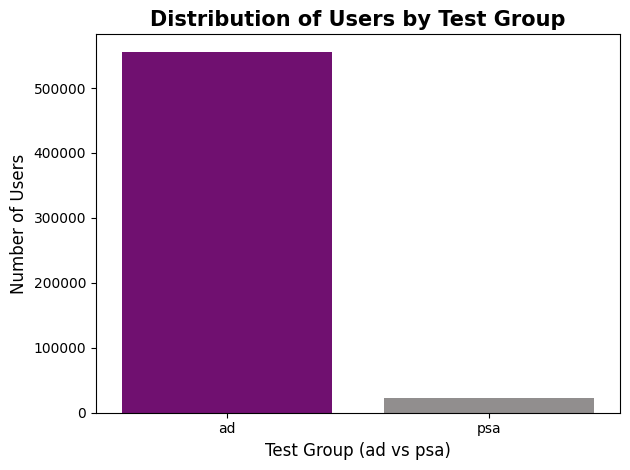

In [72]:
# Distribution of users across test groups
plt.figure()
sns.countplot(
    data=df_marketing, 
    x='test_group', 
    palette=["#800080", "#918D8D"]
)

plt.xlabel('Test Group (ad vs psa)', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.title('Distribution of Users by Test Group', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Interpretation: Distribution of Users by Test Group

Based on the chart *“Distribution of Users by Test Group”*, which compares the **ad** and **psa** groups, a significant imbalance in the number of users can be clearly observed. The **ad** group contains a much larger sample size, with **554,998 users**, while the **psa** group only has **23,072 users**. This large discrepancy is important to note because, in the context of an A/B test, the sample sizes of both groups should ideally be balanced to ensure valid and reliable results. An extreme imbalance such as this increases the risk of bias, meaning that differences in performance between groups must be interpreted with caution.

</span>

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### ✅ Overall Conclusion

The EDA results indicate that the advertising campaign had a **positive effect on conversions**, with **higher engagement during mid-day (around 14:00)** and **stronger performance on Fridays**. These findings provide a strong foundation for conducting **inferential testing (A/B testing)** to validate the effectiveness of the campaign.

</span>

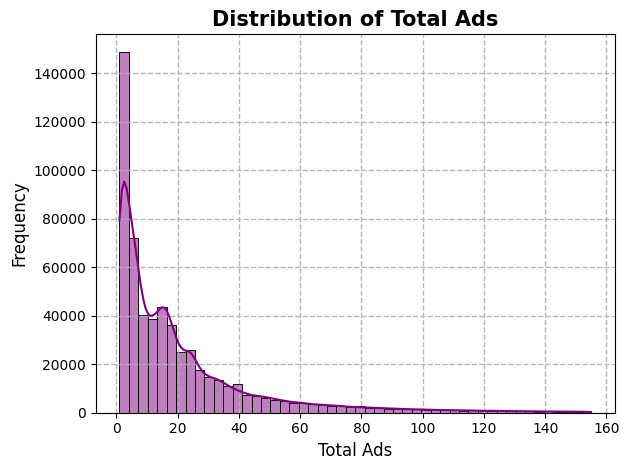

In [73]:
# Distribution of Total Ads
plt.figure()
sns.histplot(
    data=df_marketing,
    x='total_ads',
    bins = 50,
    kde=True,
    color='#800080'
)

plt.title('Distribution of Total Ads', fontsize=15, fontweight='bold')
plt.xlabel('Total Ads', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(
    True,
    which='both',
    linestyle='--',
    linewidth=1,
    alpha=0.9
)

plt.tight_layout()
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Interpretation: Distribution of Total Ads

From the chart of **total_ads distribution**, it can be observed that most users are exposed to a relatively small number of ads, typically ranging from **1 to 10 impressions**. The distribution is **right-skewed**, indicating that only a small portion of users see a very large number of ads. This pattern suggests that the campaign primarily reaches users with low exposure frequency, while only a few users are targeted intensively, creating outliers that must be carefully considered or further analyzed. From a business perspective, it is crucial to evaluate the effectiveness of ad impressions on conversion, as there may be a saturation point where increasing the number of ads no longer significantly impacts campaign success.

</span>

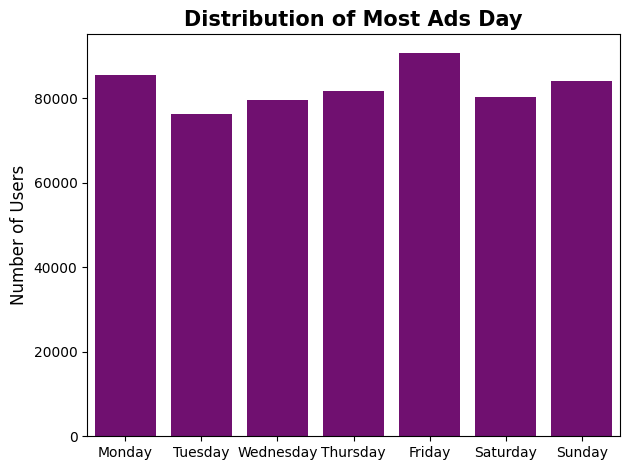

In [74]:
# Distribution of Most Ads Day
day_map = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure()
sns.countplot(
    data=df_marketing,
    x='most_ads_day',
    order=day_map,
    color="#800080"
)

plt.xlabel('')
plt.ylabel('Number of Users', fontsize=12)
plt.title('Distribution of Most Ads Day', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Interpretation: Distribution of Most Ads Day

The results from the **Distribution of Most Ads Day** chart show that, in general, users view ads relatively evenly throughout the week, with the highest peak occurring on **Friday** and the lowest on **Tuesday**, although the difference is not very significant. This indicates that ad exposure is relatively balanced across days. However, **Friday** can be considered the most effective day in terms of the number of users exposed to ads, making it a strategic opportunity to increase advertising budgets on that day and showcase the most important content or promotions.

</span>

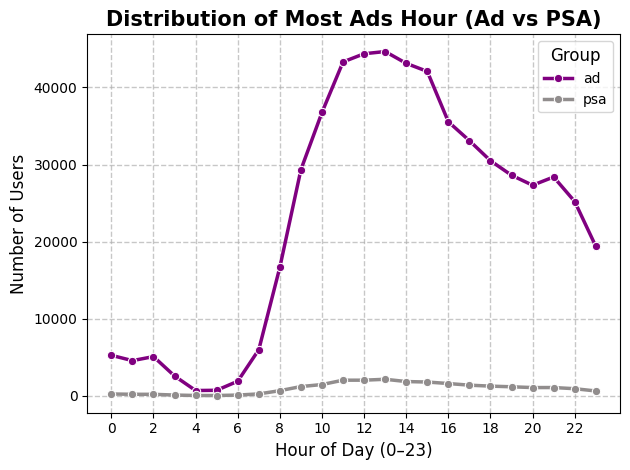

In [75]:
# Distribution of Most Ads Hour (Ad vs PSA)
hourly_dist = df_marketing.groupby(['most_ads_hour', 'test_group']).size().reset_index(name='count')

plt.figure()
sns.lineplot(
    data=hourly_dist,
    x='most_ads_hour',
    y='count',
    hue='test_group',
    marker='o',
    linewidth=2.5,
    palette=["#800080", "#918D8D"]
)

plt.title('Distribution of Most Ads Hour (Ad vs PSA)', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(np.arange(0, 24, 2))

plt.grid(
    True,
    which='both',
    linestyle='--',
    linewidth=1,
    alpha=0.7
)

plt.legend(title='Group',
           fontsize=10,
           title_fontsize=12,
           loc='upper right')

plt.tight_layout()
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Interpretation: Distribution of Most Ads Hour by Group

**Group "ad"**  
The majority of users view ads between **10:00 and 16:00**, with the highest peak at **14:00**. This indicates that most users are exposed to ads during the late morning to afternoon period. After **16:00**, the number of users viewing ads gradually declines.

**Group "psa"**  
The number of users exposed to PSA ads is much lower compared to commercial ads. The distribution appears relatively flat and stable throughout the day, with a slight increase between **10:00 and 14:00**, but without any significant spikes. This suggests that PSA ads are less influenced by the time of day, or their distribution is simply more even across the day.

By understanding these trends, ad placements can be optimized during the most effective hours, especially for commercial ads.  

</span>

C:\Users\Asus\AppData\Local\Temp\ipykernel_15476\2250670094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


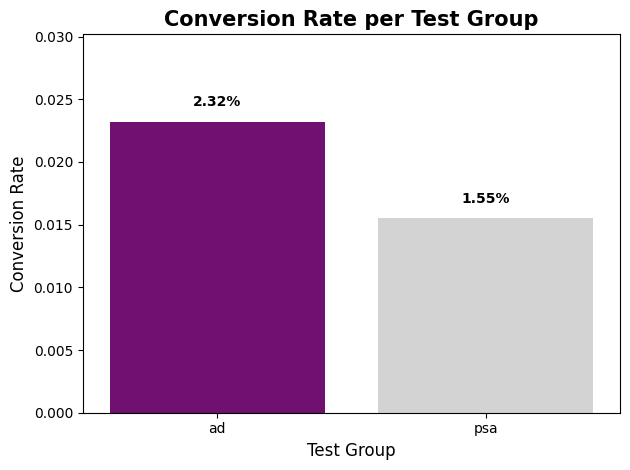

In [76]:
# Conversion Rate per Test Group
mean_converted = df_marketing.groupby('test_group')['converted'].mean().reset_index()

plt.figure()
ax = sns.barplot(
    data=mean_converted, 
    x='test_group', 
    y='converted',
    palette=['#800080', '#D3D3D3']
)

for i, v in enumerate(mean_converted['converted']):
    ax.text(i, v + 0.001, f"{v:.2%}", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Conversion Rate per Test Group', fontsize=15, fontweight='bold')
plt.xlabel('Test Group', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.ylim(0, mean_converted['converted'].max() * 1.3)  

plt.tight_layout()
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Interpretation: Conversion Rate per Test Group

The chart *Conversion Rate per Test Group* shows that the **ad group** has a conversion rate of **2.32%**, which is higher than the **psa group** at **1.55%**. This difference is also influenced by the imbalance in sample size between the two groups. From a business perspective, this finding indicates that the advertising campaign had a positive impact on user behavior by increasing the likelihood of conversion compared to showing only a PSA. However, to ensure that this difference is statistically significant, an inferential test (such as a Z-test for proportions) is required, so that the results are more reliable and not solely based on observed numerical differences.

</span>

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

# **Assumptions and Validity Check for Z-Test in A/B Marketing Experiment**

**Purpose of the Analysis**  
The main objective of this A/B testing analysis is to compare user behavior between two groups (`ad` and `psa`) in terms of conversion rates, in order to answer two key questions:  
1. Did the advertising campaign succeed in increasing conversions?  
2. If so, how much of that success can be directly attributed to the advertisement?  

---

**Hypotheses**  
- **Null Hypothesis (H0):** No difference in conversion rates between `ad` and `psa`.  
  → H0: *p<sub>ad</sub>* = *p<sub>psa</sub>*  

- **Alternative Hypothesis (H1):** Conversion rate in `ad` group is higher than `psa`.  
  → H1: *p<sub>ad</sub>* > *p<sub>psa</sub>*  

---

**Data and Challenges**  
After data cleaning, validation, and EDA, a significant imbalance was found:  
- Ad group: 554,998 users  
- PSA group: 23,072 users  

To avoid loss of information, the **full dataset** was used without resampling.  

---

**Assumption Checks for Z-Test**  
1. **Data Grouping** → Dataset divided into two groups: `ad` and `psa`.  
2. **Duplicate User ID Check** → No duplicates found within groups.  
3. **Overlapping User ID Check** → No user appears in both groups (independent samples).  
4. **Normal Approximation Check** → Expected successes (*n × p̂*) ≥ 10 and expected failures (*n × (1 − p̂)*) ≥ 10 for both groups.  
5. **Group Size Ratio** → Ratio of ad group size compared to psa calculated for consideration.  

---

</span>

In [77]:
# 1. A/B Testing: Split Data into Treatment and Control Groups
treatment = df_marketing[df_marketing['test_group'] == 'ad']
control   = df_marketing[df_marketing['test_group'] == 'psa']

id_col = 'user_id'

# 2. Check duplicates within groups
control_dupes   = control.duplicated(subset=id_col).sum()
treatment_dupes = treatment.duplicated(subset=id_col).sum()

# 3. Check overlapping users between groups
control_ids     = set(control[id_col])
treatment_ids   = set(treatment[id_col])
overlapping_ids = control_ids & treatment_ids

# 4. Cek Normal Approximation
def check_normality(df, target_col='converted'):
    p = df[target_col].mean() # estimator p-hat
    n = len(df)               # sample size
    successes = n * p         # expected successes
    failures  = n * (1 - p)   # expected failures
    return successes, failures, successes >= 10 and failures >= 10

c_succ, c_fail, c_ok = check_normality(control, 'converted')
t_succ, t_fail, t_ok = check_normality(treatment, 'converted')

# 4. Group size ratio 
group_ratio = len(treatment) / len(control)

# 5. Decision
assumptions_df = pd.DataFrame({
    'Metric': [
        'Expected Successes (n*p)',
        'Expected Failures (n*(1-p))',
        'Normal Approximation OK?',
        'Duplicate user_id',
        'Overlapping user_id',
        'Group Size Ratio (T/C)'
    ],
    'Control': [
        round(c_succ, 1),
        round(c_fail, 1),
        c_ok,
        control_dupes,
        len(overlapping_ids),
        None
    ],
    'Treatment': [
        round(t_succ, 1),
        round(t_fail, 1),
        t_ok,
        treatment_dupes,
        len(overlapping_ids),
        round(group_ratio, 2)
    ]
})

print('\n=== Assumption Check ===')
print(assumptions_df.to_string(index=False))


=== Assumption Check ===
                     Metric  Control Treatment
   Expected Successes (n*p)    358.0   12882.0
Expected Failures (n*(1-p))  22714.0  542116.0
   Normal Approximation OK?     True      True
          Duplicate user_id        0         0
        Overlapping user_id        0         0
     Group Size Ratio (T/C)     None     24.06


<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### Interpretation of Z-Test Assumption Check  

Based on the results table:  

1. **Expected Successes (n × p):** Both *ad* and *psa* groups have expected successes ≥ 10, fulfilling the requirement for using the normal approximation to proportions.  

2. **Expected Failures (n × (1 − p)):** Both groups also have expected failures ≥ 10, further supporting the validity of the normal approximation.  

3. **Normal Approximation Check:** Both the control and treatment groups meet the criteria, indicating that the Z-Test can be applied appropriately.  

4. **Duplicate user_id:** No duplicates were found in either group (= 0), meaning the data within each group is independent.  

5. **Overlapping user_id:** No users appear in both groups (= 0), ensuring that the two samples are truly independent.  

6. **Group Size Ratio (Treatment / Control):** The ratio of users between the treatment and control groups is approximately **24 : 1**. This reflects a significant imbalance in sample sizes. While this does not violate Z-Test assumptions, it should be noted because it can affect the practical interpretation of results (e.g., the smaller group is more vulnerable to variance fluctuations).  

7. **Conclusion:** All key assumptions for conducting a Z-Test are satisfied (*normal approximation valid, no duplicates, no overlap*). Therefore, the **Two-Proportion Z-Test can be carried out**. However, results should still be interpreted with caution due to the large imbalance in sample sizes (**24 times difference**).  

</span>

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### A/B Testing Marketing with Z-Test

After confirming that the assumptions for the Z-Test were satisfied, the following steps were carried out in the A/B testing process:

1. **Calculate Conversion Rate & Difference**  
   - Compute the conversion rate for the control group (*psa*) and the treatment group (*ad*).  
   - Calculate the absolute difference and the relative lift (percentage increase) of the treatment group compared to the control group.  

2. **Two-Proportion Z-Test**  
   - Perform a two-proportion z-test to statistically test whether the difference in conversion rates between the *ad* and *psa* groups is significant.  

3. **Confidence Interval for the Difference**  
   - Calculate the 95% confidence interval for the difference in conversion rates between the two groups as a measure of the precision of the estimated difference.  

4. **Cohen’s h (Effect Size)**  
   - Compute Cohen’s h effect size, which quantifies the practical magnitude of the difference in conversion proportions.  

5. **Power Analysis (1 - β)**  
   - Conduct a statistical power analysis to evaluate the probability of detecting a true effect given the available sample size and effect size.  

---

#### Methods Applied in Code
- **Conversion Rate** was calculated as the mean of the `converted` variable (True = 1, False = 0) within each group.  
- **Two-Proportion Z-Test** was performed using the `proportions_ztest` function from *statsmodels*, with inputs being the number of conversions and total observations for each group.  
- **Confidence Interval** was computed using the standard formula for the difference between two proportions under the normal approximation.  
- **Cohen’s h** was calculated using the arcsine transformation to measure effect size in proportions.  
- **Power Analysis** was carried out with `NormalIndPower` from *statsmodels* to compute statistical power based on effect size and sample size.  

<span>

In [78]:
# 1. Conversion Rate & Difference
cr_control   = control['converted'].mean()
cr_treatment = treatment['converted'].mean()

abs_diff = cr_treatment - cr_control
rel_lift = abs_diff / cr_control * 100

# 2. Two-Proportion Z-Test
successes = [treatment['converted'].sum(), control['converted'].sum()]
nobs      = [len(treatment), len(control)]

z_stat, p_value = sm.stats.proportions_ztest(successes, nobs)

# 3. Confidence Interval for Difference
p1, p2 = cr_treatment, cr_control
se_diff = np.sqrt((p1*(1-p1)/nobs[0]) + (p2*(1-p2)/nobs[1]))
ci_low  = abs_diff - 1.96*se_diff
ci_high = abs_diff + 1.96*se_diff

# 4. Cohen's h (effect size)
cohen_h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

# 5. Power Analysis (1 - beta)
analysis = smp.NormalIndPower()
power = analysis.solve_power(effect_size=cohen_h, nobs1=nobs[0], alpha=0.05, ratio=nobs[1]/nobs[0])

# Output
results = pd.DataFrame({
    'Metric': [
        'Control Conversion Rate',
        'Treatment Conversion Rate',
        'Absolute Difference',
        'Relative Lift',
        'Z-Statistic',
        'P-Value',
        '95% CI (Diff Lower)',
        '95% CI (Diff Upper)',
        "Cohen's h (Effect Size)",
        'Statistical Power'
    ],
     'Value': [
        f'{cr_control * 100:.2f}%',         
        f'{cr_treatment * 100:.2f}%',      
        f'{abs_diff * 100:.2f}%',          
        f'columns={rel_lift:.2f}%',                
        f'{z_stat:.4f}',
        f'{p_value:.4f}',
        f'{ci_low * 100:.2f}%',          
        f'{ci_high * 100:.2f}%',           
        f'{cohen_h:.4f}',
        f'{power:.4f}'
    ]
})

print('\n=== A/B Test Results ===')
print(results.to_string(index=False))


=== A/B Test Results ===
                   Metric          Value
  Control Conversion Rate          1.55%
Treatment Conversion Rate          2.32%
      Absolute Difference          0.77%
            Relative Lift columns=49.59%
              Z-Statistic         7.6549
                  P-Value         0.0000
      95% CI (Diff Lower)          0.61%
      95% CI (Diff Upper)          0.93%
  Cohen's h (Effect Size)         0.0561
        Statistical Power         1.0000


<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### Interpretation of A/B Test Results

The advertising campaign proved effective in increasing conversions. Based on the A/B testing results, the **ad group** achieved a conversion rate of **2.32%**, compared to **1.55%** in the **psa group**, yielding an absolute difference of **0.77%** and a **relative lift of 49.59%**.  

The Z-Test results show a **z-statistic of 7.65** (greater than +1.96) and a **p-value < 0.005**, indicating that **H0 is rejected** and **H1 is accepted**. The **95% confidence interval (0.61% – 0.93%)** confirms that the increase in conversion rate can be attributed directly to the ad campaign rather than chance.  

Although the effect size (Cohen’s h = 0.0561) is considered small, meaning the practical impact per user is limited, the large dataset amplifies the significance of the results. Furthermore, the **power analysis shows a value of 1.0 (100%)**, which indicates that the test had very high sensitivity to detect real differences.  

In conclusion, the ad campaign significantly outperformed PSA in driving conversions. While the practical effect is modest, the business impact remains meaningful, as even small improvements at scale can generate substantial revenue growth.

</span>

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

## 🔎 Interpretation After A/B Testing Results

Although the A/B test results indicate an increase in conversions — where the ad group achieved a higher conversion rate than the PSA group — the effect size analysis (Cohen’s h) suggests that the improvement is very small in practical terms. In other words, the difference is statistically significant but has limited real-world impact on user behavior.

Another important limitation is the imbalance in group sizes:  
- **Ad group** → ~555,000 users  
- **PSA group** → ~23,000 users  

This imbalance does not violate the assumptions of the Z-test, but it can influence the accuracy of effect estimation and make interpretations more prone to bias. For this reason, the full dataset was kept without undersampling to preserve all available information.

---

### 🎯 Focus for Further Analysis: Conversion Timing
Instead of relying solely on the A/B test results, the analysis continues with a focus on *time-based conversion patterns*. The goal is to identify the days and hours with the highest conversion rates in order to optimize campaign scheduling.

---

### 🔍 Variables Used
- **most_ads_day** → day with the highest number of ad exposures  
- **most_ads_hour** → hour with the highest number of ad exposures  
- **is_weekend** → whether the day falls on a weekend  
- **time_of_day** → time category (morning, afternoon, evening, night)  

---

### 🎯 Objectives of Time-Based Analysis
- Identify the days and hours with the highest conversion rates  
- Understand behavioral patterns related to timing  
- Provide strategic recommendations to:  
  - Increase ad delivery during high-conversion hours  
  - Reduce allocation during low-performing periods  
  - Optimize campaign operational costs  

---

### 🔄 Long-Term Strategic Potential
If time-based analysis successfully reveals consistent improvement in conversions, a *time optimization strategy* can be integrated into future campaigns. In the next iteration, the company could:  
- Balance the number of users in each group from the start  
- Adjust ad scheduling based on identified optimal time slots  
- Evaluate conversion impact more fairly and accurately  

---

### 💡 Expected Outcome
By understanding the optimal times for conversions, the company can increase campaign effectiveness, reduce cost per acquisition, and design follow-up A/B tests that are more targeted and reliable to support stronger business decisions.

</span>

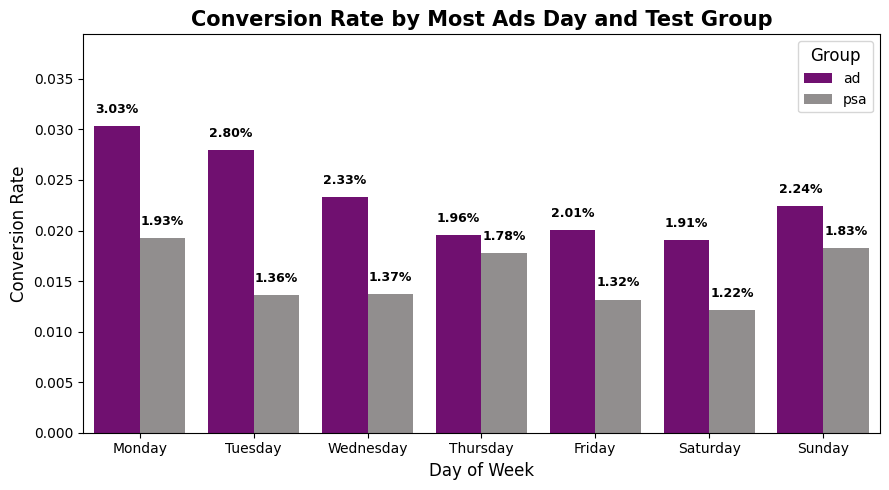

In [79]:
# Conversion Rate by Most Ads Day and Test Group

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

conversion_day = (
    df_marketing
    .groupby(['most_ads_day', 'test_group'])['converted']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'conversion_rate', 'count': 'user_count'})
)

conversion_day['most_ads_day'] = pd.Categorical(conversion_day['most_ads_day'], categories=day_order, ordered=True)

plt.figure(figsize=(9,5))
sns.barplot(
    data=conversion_day,
    x='most_ads_day',
    y='conversion_rate',
    hue='test_group',
    palette=["#800080", "#918D8D"]
)

plt.title('Conversion Rate by Most Ads Day and Test Group', fontsize=15, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.ylim(0, conversion_day['conversion_rate'].max() * 1.3)
plt.legend(title='Group', title_fontsize=12, fontsize=10)

for i, bar in enumerate(plt.gca().patches):
    height = bar.get_height()
    if height > 0:
        plt.gca().text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.001,
            f'{height:.2%}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Conversion Rate (ad vs psa) by Day of Week

The chart shows that the highest conversion rates for both groups occur on **Monday**, with **Ad reaching 3.03%** and **PSA 1.93%**, while the lowest conversion rates are observed on **Saturday** (Ad 1.91% and PSA 1.22%). This pattern suggests that users are more likely to convert at the beginning of the week compared to the weekend. For the **Ad group**, conversions remain relatively strong during the early week (Monday to Wednesday), whereas the **PSA group** performs better on **Monday, Sunday, and Thursday**. Overall, this confirms that ads consistently achieve higher conversion rates than PSA across all days, although day-to-day variations are still evident.

</span>

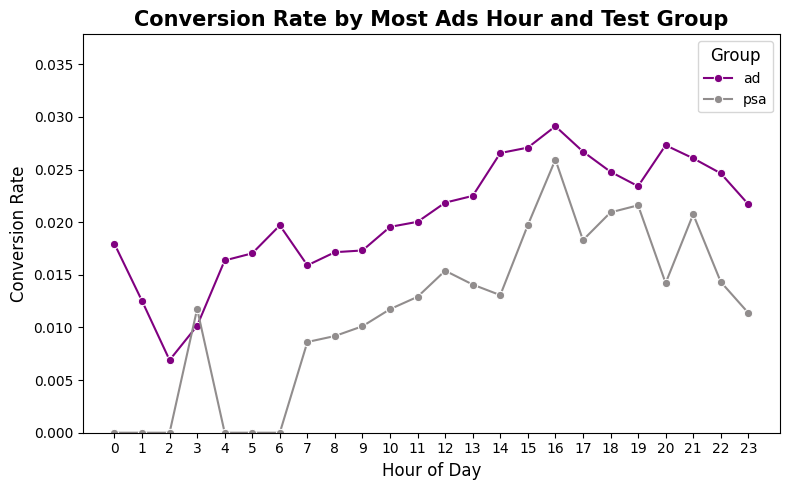

In [80]:
# Conversion Rate by Most Ads Hour and Test Group
conversion_hour = (
    df_marketing
    .groupby(['most_ads_hour', 'test_group'])['converted']
    .mean()
    .reset_index(name='conversion_rate')
)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=conversion_hour,
    x='most_ads_hour',
    y='conversion_rate',
    hue='test_group',
    marker='o',
    palette=["#800080", "#918D8D"]
)

plt.title('Conversion Rate by Most Ads Hour and Test Group', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.xticks(list(range(24)))
plt.ylim(0, conversion_hour['conversion_rate'].max() * 1.3)
plt.legend(title='Group', title_fontsize=12, fontsize=10)

plt.tight_layout()
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Conversion Rate (ad vs psa) by most_ads_hour

The chart **Conversion Rate by Most Ads Hour and Test Group** shows that the Ad group experiences a steady but modest increase in conversion rates from 6 AM to around 1 PM, followed by a clear peak between 1 PM and 5 PM (reaching approximately 2.6%–2.9%). After 8 PM through 2 AM, the conversion rate declines significantly. In comparison, the PSA group also shows its highest conversion rates during the afternoon, with a peak between 2 PM and 5 PM, though consistently lower than the Ad group. Overall, both groups indicate that the afternoon hours (particularly 1 PM to 5 PM) are the most effective time window for conversions, with the Ad group maintaining a stronger performance throughout the day.

</span>

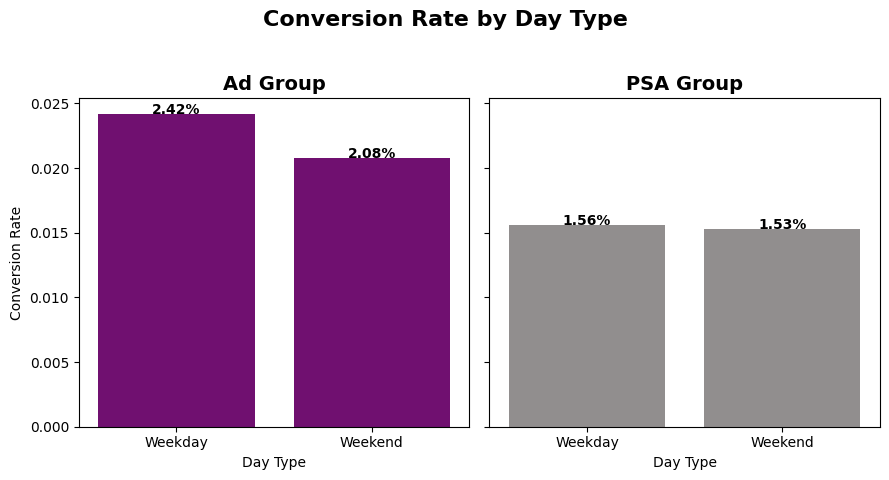

In [81]:
# Conversion Rate by Day Type
ad_conversion = treatment.groupby('is_weekend')['converted'].mean().reset_index(name='conversion_rate')
psa_conversion = control.groupby('is_weekend')['converted'].mean().reset_index(name='conversion_rate')

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(9,5))

sns.barplot(
    data=ad_conversion, 
    x='is_weekend', 
    y='conversion_rate', 
    ax=axes[0], 
    color="#800080"
)
axes[0].set_title('Ad Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xlabel('Day Type')

sns.barplot(
    data=psa_conversion, 
    x='is_weekend', 
    y='conversion_rate', 
    ax=axes[1], 
    color="#918D8D"
)
axes[1].set_title('PSA Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Day Type')

for ax in axes:
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width()/2, 
            height + 0.000, 
            f'{height:.2%}', 
            ha='center', 
            fontsize=10, 
            fontweight='bold'
        )


plt.suptitle('Conversion Rate by Day Type', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Conversion Rate (ad vs psa) by Day Type

- The Ad group shows stronger performance on weekdays (2.42%) compared to weekends (2.08%), suggesting that users tend to be more responsive to ads during weekdays possibly because they are in their normal routines, more focused, or actively searching for specific needs (e.g., during work breaks).  
- In contrast, the PSA group demonstrates stable performance across both weekdays (1.56%) and weekends (1.53%), indicating that non-commercial announcements are not significantly influenced by timing, or perhaps because users are generally less engaged with PSA content in the context of purchasing behavior.

</span>

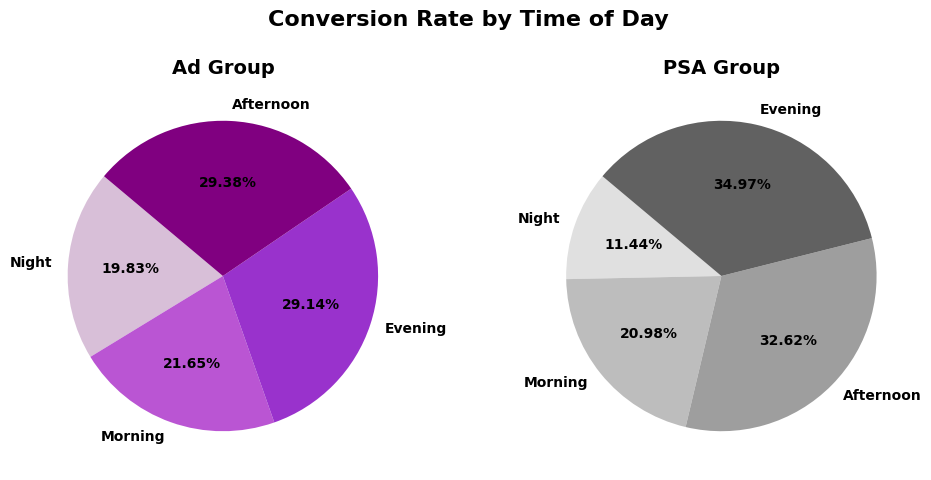

In [82]:
# Conversion Rate by Time of Day
ad_conversion = (
    treatment.groupby('time_of_day')['converted']
    .mean()
    .reset_index(name='conversion_rate')
    .sort_values('conversion_rate') 
)

psa_conversion = (
    control.groupby('time_of_day')['converted']
    .mean()
    .reset_index(name='conversion_rate')
    .sort_values('conversion_rate')
)

purple_gradient = ['#D8BFD8', '#BA55D3', '#9932CC', '#800080']
grey_gradient = ['#E0E0E0', '#BDBDBD', '#9E9E9E', '#616161']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].pie(
    ad_conversion['conversion_rate'],
    labels=ad_conversion['time_of_day'],
    autopct='%1.2f%%',
    startangle=140,
    colors=purple_gradient,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
axes[0].set_title('Ad Group', fontsize=14, fontweight='bold')

axes[1].pie(
    psa_conversion['conversion_rate'],
    labels=psa_conversion['time_of_day'],
    autopct='%1.2f%%',
    startangle=140,
    colors=grey_gradient,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
axes[1].set_title('PSA Group', fontsize=14, fontweight='bold')

plt.suptitle('Conversion Rate by Time of Day', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

### 📊 Conversion Rate (ad vs psa) by Time of Day

The Ad group shows the highest conversion rates during the afternoon (29.38%) and evening (29.14%), while the lowest occurs at night (19.83%). Similarly, the PSA group also peaks in the evening (34.97%) and afternoon (32.62%), with significantly lower engagement at night (11.44%). This suggests that users are generally more active and responsive to both ads and PSA messages during the day, particularly in the afternoon and evening, when they are likely to be more relaxed, have more free time, or are browsing online after work or school. Conversely, late-night hours tend to yield the lowest conversions, likely due to reduced user activity and engagement levels during those times.

</span>

<span style="font-family: 'Times New Roman'; font-size: 12pt;">

# ✅ Final Conclusion of A/B Testing & Time Trends

Based on the A/B testing results, the Ad group consistently shows a higher conversion rate compared to the PSA group, and this difference is statistically significant, although the effect size is relatively small in practical terms.  

However, one important issue must be noted: there is a large imbalance in the number of users between the Ad and PSA groups, which means the experimental results should be interpreted with caution. Nevertheless, further analysis across time dimensions (day, hour, and time of day) revealed conversion patterns that can be leveraged for real optimization of marketing strategies.  

---

## 📊 Key Findings from Time Trend Analysis  

**Best Days:**  
- Highest conversion occurred on **Monday** for both groups.  
- **Saturday** showed the lowest performance, making it the least effective time for ads.  

**Best Hours:**  
- **1 PM – 5 PM (Afternoon)** was the peak conversion period.  
- Late-night hours (**after 8 PM until early morning**) saw a significant drop in conversions.  

**Day Type (Weekday vs Weekend):**  
- The Ad group performed better on **weekdays**, indicating users are more responsive during work routines.  
- The PSA group remained relatively stable, with no meaningful difference between weekdays and weekends.  

**Time of Day (Category):**  
- **Afternoon and Evening** were the most optimal windows for ad placements.  
- **Night time** showed the weakest performance for both groups.  

---

## Strategic Recommendations for Business  

Here are data-driven recommendations aimed at creating real business impact:  

1. 🎯 **Optimize Ad Scheduling**  
   Focus ad placements on:  
   - **Weekdays (especially Monday to Wednesday)**  
   - **1 PM – 5 PM and 5 PM – 8 PM**  
   These are the hours when users are most responsive to ads, improving budget efficiency without increasing ad volume.  

2. 💤 **Reduce Exposure in Low-Impact Periods**  
   Minimize ad spending on **Saturdays** and during **late-night hours (after 8 PM)**.  
   This will help reduce costs on slots that do not deliver significant conversions.  

3. 📈 **Re-test A/B Experiment with Balanced Design**  
   Once time-based strategies improve performance, run another A/B test with **balanced user allocation** between Ad and PSA groups.  
   This will yield a more accurate effect size and strengthen the validity of strategic decisions going forward.  

4. 💡 **Leverage Automation & Machine Learning**  
   With these time-based patterns identified, the company can start building **predictive models** for optimal ad timing or use **automated ad scheduling** aligned with peak conversion windows.  

---

## 📌 Closing Note  

Instead of only focusing on “which group performs better,” this approach emphasizes leveraging **user behavioral patterns over time** to maximize campaign effectiveness at minimal cost. This represents a concrete application of **data-driven decision-making** — going beyond A/B test results and turning insights into actionable business strategies.  

</span>